## Data Preparation

In [1]:
# import the necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# read in the given dataset
df = pd.read_csv('AirtrafficA4.csv')
df

,AIRLINE,YEAR,MONTH,TOTAL DEPARTURES,HOURS FLOWN,KILOMETRE FLOWN,PASSENGERS CARRIED,AVAILABLE SEAT KILOMETRE (IN THOUSAND),FREIGHT CARRIED (IN TONNE),MAIL CARRIED (IN TONNE)
0,A007,2023,JAN,"47,977","83,764","41,827","68,47,384","78,32,254","16,881.70","2,043.5"
1,A007,2023,FEB,"44,905","77,936","39,121","67,41,948","73,36,614","17,439.30","2,086.7"
2,A007,2023,MAR,"50,389","87,296","43,793","73,17,288","82,15,681","20,208.40","2,310.1"
3,A007,2023,APR,"48,752","84,232","42,615","74,06,440","80,05,648","19,432.80","2,102.9"
4,A007,2023,MAY,"50,956","87,917","44,505","81,09,626","83,75,201","24,165.10","2,102.4"
...,...,...,...,...,...,...,...,...,...,...
123,A007,2013,AUG,"12,278","21,571","11,884","15,31,406","21,39,007","9,600.00",0
124,A007,2013,SEP,"12,185","21,281","11,749","13,78,691","21,14,792","8,492.00",0
125,A007,2013,OCT,"12,780","22,345","12,296","15,10,184","22,13,139","9,111.00",0
126,A007,2013,NOV,"12,357","21,837","11,904","14,67,763","21,42,765","7,185.00",0


In [3]:
# for use with sktime library, the data should be indexed by a periodic time index
# in this case, the data is monthly, so we can use a monthly frequency 
# df.index = pd.PeriodIndex(pd.to_datetime(df['YEAR'].astype(str) + '-' + df['MONTH'].str[:3], format='%Y-%b'), freq='M')
date_col = df['YEAR'].astype(str) + '-' + df['MONTH'].str[:3]
df.index = pd.PeriodIndex(pd.to_datetime(date_col, format='%Y-%b'), freq='M')
df

,AIRLINE,YEAR,MONTH,TOTAL DEPARTURES,HOURS FLOWN,KILOMETRE FLOWN,PASSENGERS CARRIED,AVAILABLE SEAT KILOMETRE (IN THOUSAND),FREIGHT CARRIED (IN TONNE),MAIL CARRIED (IN TONNE)
2023-01,A007,2023,JAN,"47,977","83,764","41,827","68,47,384","78,32,254","16,881.70","2,043.5"
2023-02,A007,2023,FEB,"44,905","77,936","39,121","67,41,948","73,36,614","17,439.30","2,086.7"
2023-03,A007,2023,MAR,"50,389","87,296","43,793","73,17,288","82,15,681","20,208.40","2,310.1"
2023-04,A007,2023,APR,"48,752","84,232","42,615","74,06,440","80,05,648","19,432.80","2,102.9"
2023-05,A007,2023,MAY,"50,956","87,917","44,505","81,09,626","83,75,201","24,165.10","2,102.4"
...,...,...,...,...,...,...,...,...,...,...
2013-08,A007,2013,AUG,"12,278","21,571","11,884","15,31,406","21,39,007","9,600.00",0
2013-09,A007,2013,SEP,"12,185","21,281","11,749","13,78,691","21,14,792","8,492.00",0
2013-10,A007,2013,OCT,"12,780","22,345","12,296","15,10,184","22,13,139","9,111.00",0
2013-11,A007,2013,NOV,"12,357","21,837","11,904","14,67,763","21,42,765","7,185.00",0


In [4]:
# we can now drop the year and month columns
# the airline column is also dropped because it is the same throughout and has no predictive power
df = df.drop(columns=['YEAR', 'MONTH', 'AIRLINE'])
df

,TOTAL DEPARTURES,HOURS FLOWN,KILOMETRE FLOWN,PASSENGERS CARRIED,AVAILABLE SEAT KILOMETRE (IN THOUSAND),FREIGHT CARRIED (IN TONNE),MAIL CARRIED (IN TONNE)
2023-01,"47,977","83,764","41,827","68,47,384","78,32,254","16,881.70","2,043.5"
2023-02,"44,905","77,936","39,121","67,41,948","73,36,614","17,439.30","2,086.7"
2023-03,"50,389","87,296","43,793","73,17,288","82,15,681","20,208.40","2,310.1"
2023-04,"48,752","84,232","42,615","74,06,440","80,05,648","19,432.80","2,102.9"
2023-05,"50,956","87,917","44,505","81,09,626","83,75,201","24,165.10","2,102.4"
...,...,...,...,...,...,...,...
2013-08,"12,278","21,571","11,884","15,31,406","21,39,007","9,600.00",0
2013-09,"12,185","21,281","11,749","13,78,691","21,14,792","8,492.00",0
2013-10,"12,780","22,345","12,296","15,10,184","22,13,139","9,111.00",0
2013-11,"12,357","21,837","11,904","14,67,763","21,42,765","7,185.00",0


In [5]:
# we also have to convert all the columns from strings to numerical values
# this is done by first removing the ',' and then converting to floats
# NOTE: features like 'PASSENGERS CARRIED' are actually integral, but it doesn't affect the forecasting
df = df.apply(lambda col: col.str.replace(',', '').astype(float))
df

,TOTAL DEPARTURES,HOURS FLOWN,KILOMETRE FLOWN,PASSENGERS CARRIED,AVAILABLE SEAT KILOMETRE (IN THOUSAND),FREIGHT CARRIED (IN TONNE),MAIL CARRIED (IN TONNE)
2023-01,47977.0,83764.0,41827.0,6847384.0,7832254.0,16881.7,2043.5
2023-02,44905.0,77936.0,39121.0,6741948.0,7336614.0,17439.3,2086.7
2023-03,50389.0,87296.0,43793.0,7317288.0,8215681.0,20208.4,2310.1
2023-04,48752.0,84232.0,42615.0,7406440.0,8005648.0,19432.8,2102.9
2023-05,50956.0,87917.0,44505.0,8109626.0,8375201.0,24165.1,2102.4
...,...,...,...,...,...,...,...
2013-08,12278.0,21571.0,11884.0,1531406.0,2139007.0,9600.0,0.0
2013-09,12185.0,21281.0,11749.0,1378691.0,2114792.0,8492.0,0.0
2013-10,12780.0,22345.0,12296.0,1510184.0,2213139.0,9111.0,0.0
2013-11,12357.0,21837.0,11904.0,1467763.0,2142765.0,7185.0,0.0


In [6]:
# we now turn our attention to the missing values
df[df.isna().any(axis=1)]

,TOTAL DEPARTURES,HOURS FLOWN,KILOMETRE FLOWN,PASSENGERS CARRIED,AVAILABLE SEAT KILOMETRE (IN THOUSAND),FREIGHT CARRIED (IN TONNE),MAIL CARRIED (IN TONNE)
2020-03,32233.0,56567.0,28386.0,3793464.0,4985152.0,15280.6,NaN
2020-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# the ARIMA model of sktime requires that the data is continuous
# therefore, we are not able to drop these rows 
# instead, we can use interpolation to fill in the missing values
df = df.interpolate(method='time')

In [8]:
# sorting the df in chronological order
df = df.sort_index()
df

,TOTAL DEPARTURES,HOURS FLOWN,KILOMETRE FLOWN,PASSENGERS CARRIED,AVAILABLE SEAT KILOMETRE (IN THOUSAND),FREIGHT CARRIED (IN TONNE),MAIL CARRIED (IN TONNE)
2013-01,10552.0,18655.0,10112.0,1408012.0,1820105.0,6465.0,0.0
2013-02,9873.0,17374.0,9439.0,1341210.0,1698930.0,6235.0,0.0
2013-03,11393.0,20093.0,11028.0,1423569.0,1984886.0,6505.0,0.0
2013-04,11426.0,20084.0,11090.0,1511094.0,1996084.0,5903.0,0.0
2013-05,11885.0,20779.0,11533.0,1685168.0,2075882.0,7345.0,0.0
...,...,...,...,...,...,...,...
2023-04,48752.0,84232.0,42615.0,7406440.0,8005648.0,19432.8,2102.9
2023-05,50956.0,87917.0,44505.0,8109626.0,8375201.0,24165.1,2102.4
2023-06,49989.0,86217.0,43739.0,7893296.0,8254272.0,23522.6,2383.0
2023-07,52127.0,90528.0,45404.0,7674890.0,8577184.0,24885.8,2585.0


Text(0, 0.5, 'Passengers')

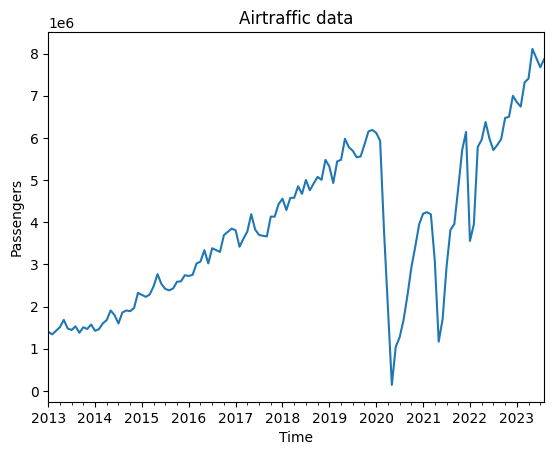

In [9]:
# We have now preprocessed the data and are ready to use it for forecasting
# Let us visualize the passenger data
df['PASSENGERS CARRIED'].plot(title='Airtraffic data')
plt.xlabel('Time')
plt.ylabel('Passengers')

In [10]:
# we now save the cleaned data to a new csv file
# so that we can use it in all the parts of this question
df.to_csv('AirtrafficA4_cleaned.csv')